# Stochastic Control & Hamilton-Jacobi-Bellman Equations

## 1. The Controlled Stochastic Differential Equation (SDE)

Consider a state $X_t \in \mathbb{R}$ governed by a **controlled SDE**:

$$dX_t = b(t, X_t, U_t)\,dt + \sigma(t, X_t)\,dW_t, \qquad X_0 = x_0$$

where:
- $U_t \in \mathcal{U}$ is the **control** we choose,
- $W_t$ is a standard Brownian motion,
- $b$ is the drift and $\sigma$ is the diffusion coefficient.

## 2. The Optimal Control Problem

We want to minimize the **expected cost** over a finite horizon $[0, T]$:

$$J(t, x; u) = \mathbb{E}\left[ \int_t^T L(s, X_s, U_s)\,ds + \Psi(X_T) \;\Big|\; X_t = x \right]$$

The **value function** is the best achievable cost:

$$V(t, x) = \inf_{u} J(t, x; u)$$

## 3. The Hamilton-Jacobi-Bellman (HJB) Equation

By the **Dynamic Programming Principle** (Bellman), the value function satisfies a nonlinear PDE called the HJB equation:

$$\partial_t V + \inf_{u \in \mathcal{U}} \left\{ L(t, x, u) + b(t, x, u)\,\partial_x V \right\} + \frac{1}{2}\sigma^2(t, x)\,\partial_{xx} V = 0$$

with terminal condition $V(T, x) = \Psi(x)$.

The optimal control is obtained in **feedback form** by minimizing the Hamiltonian:

$$u^*(t, x) = \arg\min_{u} \left\{ L(t, x, u) + b(t, x, u)\,\partial_x V \right\}$$

---

## 4. Concrete Example: Stochastic Linear-Quadratic Regulator (LQR)

To make everything visual, we study the simplest 1D stochastic LQR:

- **Dynamics:** $dX_t = U_t\,dt + \sigma\,dW_t$
- **Running cost:** $L(x, u) = q\,x^2 + r\,u^2$
- **Terminal cost:** $\Psi(x) = Q\,x^2$

For this problem, the HJB equation becomes:

$$\partial_t V + qx^2 - \frac{(\partial_x V)^2}{4r} + \frac{\sigma^2}{2}\partial_{xx} V = 0$$

Because the problem is quadratic, we guess a solution of the form:

$$V(t, x) = P(t)\,x^2 + g(t)$$

Substituting into HJB yields two ODEs:
1. **Riccati ODE:** $P'(t) = -q + \frac{P(t)^2}{r}$, with $P(T) = Q$
2. **Offset ODE:** $g'(t) = -\sigma^2 P(t)$, with $g(T) = 0$

The optimal feedback control is:

$$U^*_t = -\frac{P(t)}{r}\,X_t$$

Below, we solve this analytically, visualize it, and verify it with Monte Carlo simulation.


In [7]:
# =============================================================================
# Cell 2: Imports & Helper Functions
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# Matplotlib settings for clean, publication-style plots
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10


def safe_trapezoid(y, x):
    """
    Numerical integration using the trapezoid rule.
    Tries numpy.trapezoid first (NumPy 2.0+), falls back to manual sum.
    """
    try:
        return np.trapezoid(y, x)
    except AttributeError:
        # Manual trapezoid implementation
        return np.sum((y[:-1] + y[1:]) * np.diff(x) / 2.0)


# =============================================================================
# Problem Parameters
# =============================================================================
T = 2.0          # Time horizon
sigma = 0.5      # Noise intensity
Q = 2.0          # Terminal cost coefficient  (Psi(x) = Q*x^2)
q = 1.0          # State running cost coeff   (L includes q*x^2)
r = 1.0          # Control running cost coeff (L includes r*u^2)
x0_demo = 1.0    # Initial state for trajectory demos

# Grids
Nt = 150
Nx = 120
t = np.linspace(0.0, T, Nt)
x = np.linspace(-3.0, 3.0, Nx)


## 5. Analytical Solution of the Riccati Equation

For $q=1$, $r=1$, the Riccati ODE is:

$$P'(t) = P(t)^2 - 1, \qquad P(T) = Q = 2$$

The analytical solution can be written as:

$$\frac{P(t)-1}{P(t)+1} = \frac{Q-1}{Q+1}\,e^{2(t-T)}$$

Solving for $P(t)$ gives a time-varying feedback gain that asymptotically approaches the steady-state value $P=1$ as we move away from the terminal time.


In [8]:
# =============================================================================
# Cell 4: Solve Riccati ODE and Offset g(t) Analytically
# =============================================================================

# P(t) analytical solution
# (P - 1)/(P + 1) = alpha(t)  where alpha(t) = ((Q-1)/(Q+1)) * exp(2*(t-T))
alpha = ((Q - 1.0) / (Q + 1.0)) * np.exp(2.0 * (t - T))
P = (1.0 + alpha) / (1.0 - alpha)

# g(t) = sigma^2 * integral_t^T P(s) ds  (computed numerically for generality)
g = np.zeros(Nt)
for i in range(Nt):
    g[i] = sigma**2 * safe_trapezoid(P[i:], t[i:])

# Construct value function V(t, x) = P(t)*x^2 + g(t)  over the grid
X_grid, T_grid = np.meshgrid(x, t)
V = P[:, np.newaxis] * (X_grid ** 2) + g[:, np.newaxis]

# Optimal feedback control: u*(t, x) = -(P(t)/r) * x
U_star = -(P[:, np.newaxis] / r) * X_grid

print("P(0) =", f"{P[0]:.4f}")
print("g(0) =", f"{g[0]:.4f}")
print("Analytical V(0, x0=1) =", f"{P[0]*1.0**2 + g[0]:.4f}")


P(0) = 1.0123
g(0) = 0.5998
Analytical V(0, x0=1) = 1.6121


## 6. Visualizing the Riccati Solution

The coefficient $P(t)$ determines how aggressively we control the system. Near the terminal time $t=T$, $P$ is large because we want to force the state toward zero to avoid the high terminal cost. Far from $T$, the gain relaxes toward its steady state.


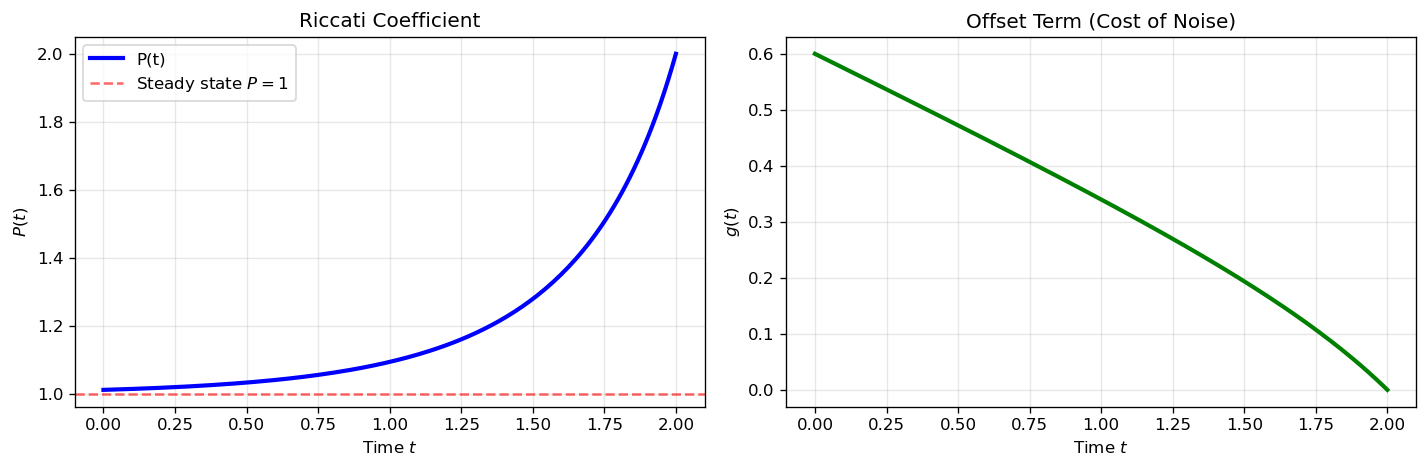

In [9]:
# =============================================================================
# Cell 6: Plot Riccati Coefficient P(t) and Offset g(t)
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# P(t)
axes[0].plot(t, P, 'b-', linewidth=2.5, label='P(t)')
axes[0].axhline(1.0, color='red', linestyle='--', alpha=0.6, label='Steady state $P=1$')
axes[0].set_xlabel('Time $t$')
axes[0].set_ylabel('$P(t)$')
axes[0].set_title('Riccati Coefficient')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# g(t)
axes[1].plot(t, g, 'g-', linewidth=2.5)
axes[1].set_xlabel('Time $t$')
axes[1].set_ylabel('$g(t)$')
axes[1].set_title('Offset Term (Cost of Noise)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 7. The Value Function $V(t, x)$

The value function is a parabola in $x$ at each time $t$, with curvature $P(t)$. It represents the "minimum expected cost to go" from any state $x$ at time $t$.


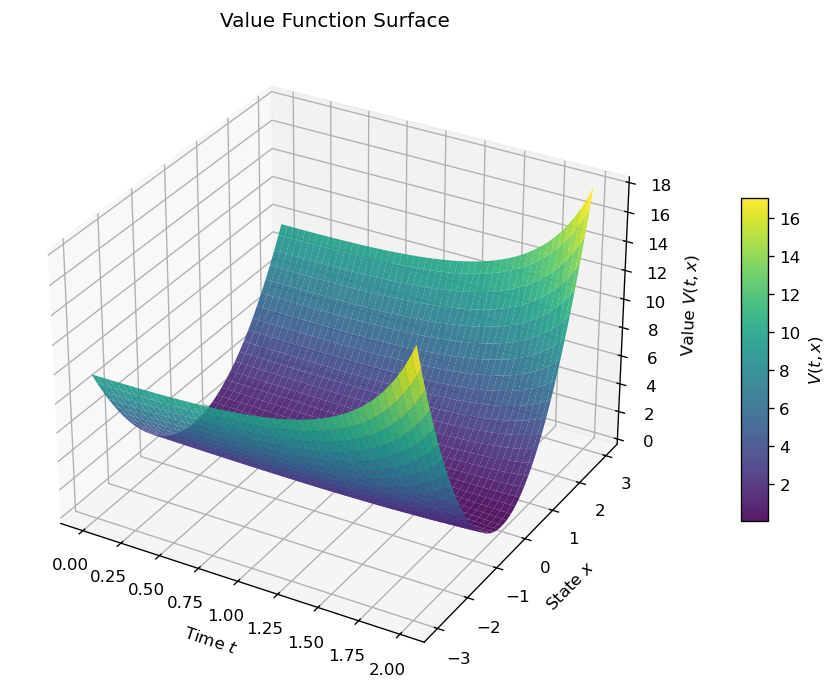

In [10]:
# =============================================================================
# Cell 8: 3D Surface Plot of Value Function
# =============================================================================
fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(T_grid, X_grid, V, cmap=cm.viridis, 
                       edgecolor='none', alpha=0.9, rstride=3, cstride=3)
ax.set_xlabel('Time $t$')
ax.set_ylabel('State $x$')
ax.set_zlabel('Value $V(t,x)$')
ax.set_title('Value Function Surface')

cbar = fig.colorbar(surf, shrink=0.5, aspect=12, pad=0.08)
cbar.set_label('$V(t,x)$')
plt.show()


## 8. Cross-Sections of the Value Function

Plotting $V(t, x)$ versus $x$ at several fixed times shows how the "cost-to-go" changes as we approach the terminal horizon.


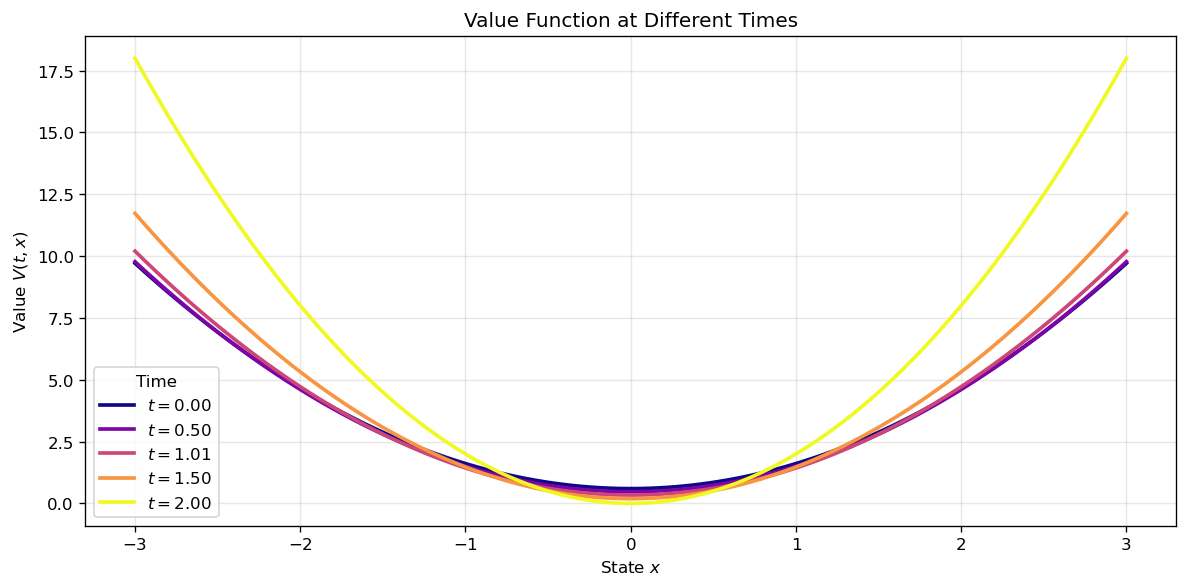

In [11]:
# =============================================================================
# Cell 10: Value Function Slices at Different Times
# =============================================================================
fig, ax = plt.subplots(figsize=(10, 5))

time_indices = [0, Nt//4, Nt//2, 3*Nt//4, Nt-1]
colors = cm.plasma(np.linspace(0, 1, len(time_indices)))

for idx, color in zip(time_indices, colors):
    label_text = rf"$t = {t[idx]:.2f}$"
    ax.plot(x, V[idx, :], color=color, linewidth=2.2, label=label_text)

ax.set_xlabel('State $x$')
ax.set_ylabel('Value $V(t,x)$')
ax.set_title('Value Function at Different Times')
ax.legend(title='Time')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 9. Optimal Feedback Policy

The optimal control is linear in the state: $u^*(t, x) = -K(t)\,x$ where $K(t) = P(t)/r$. 

In the plot below, the **background color** shows the value function, and the **red arrows** show the direction and magnitude of the optimal control at each point $(t, x)$. Notice that the control always pushes the state back toward zero (negative feedback).


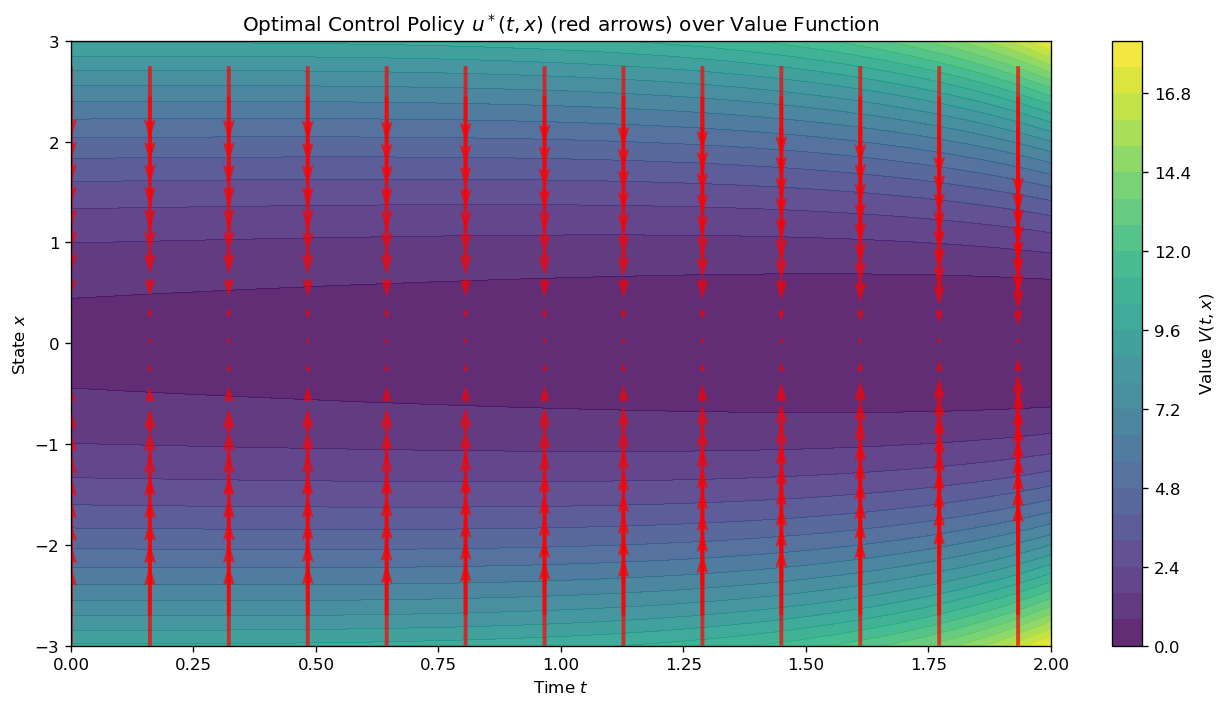

In [12]:
# =============================================================================
# Cell 12: Optimal Control Policy Visualization
# =============================================================================
fig, ax = plt.subplots(figsize=(11, 6))

# Background: value function contours
cs = ax.contourf(T_grid, X_grid, V, levels=25, cmap=cm.viridis, alpha=0.85)
plt.colorbar(cs, ax=ax, label='Value $V(t,x)$')

# Quiver: optimal control direction (only vertical since u affects x directly)
skip_t = 12
skip_x = 6
scale_factor = 0.4  # Scale arrows for visibility

ax.quiver(
    T_grid[::skip_t, ::skip_x], 
    X_grid[::skip_t, ::skip_x],
    np.zeros_like(U_star[::skip_t, ::skip_x]),
    U_star[::skip_t, ::skip_x] * scale_factor,
    color='red', alpha=0.7, width=0.004, scale=15
)

ax.set_xlabel('Time $t$')
ax.set_ylabel('State $x$')
ax.set_title('Optimal Control Policy $u^*(t,x)$ (red arrows) over Value Function')
plt.tight_layout()
plt.show()


## 10. Simulating Controlled Trajectories

We compare three strategies using **Euler-Maruyama** simulation:

1. **Optimal control:** $u_t = -P(t)\,X_t$
2. **No control:** $u_t = 0$ (pure Brownian motion with drift)
3. **Suboptimal constant gain:** $u_t = -0.3\,X_t$

The optimal controller actively damps the noise and keeps trajectories close to zero, minimizing the quadratic cost.


In [13]:
# =============================================================================
# Cell 14: SDE Simulation Engine
# =============================================================================
np.random.seed(42)  # Reproducibility


def simulate_sde(x0, T, sigma, P_profile, t_profile, n_paths=20, dt=0.005, 
                 control_type='optimal'):
    """
    Simulate dX = u(t,X) dt + sigma dW with different control strategies.
    
    control_type:
        'optimal'   -> u = -(P(t)/r) * X
        'none'      -> u = 0
        'suboptimal'-> u = -0.3 * X  (constant suboptimal gain)
    """
    n_steps = int(T / dt)
    t_sim = np.linspace(0.0, T, n_steps + 1)
    paths = np.zeros((n_paths, n_steps + 1))
    running_costs = np.zeros(n_paths)
    paths[:, 0] = x0
    
    for i in range(n_steps):
        dW = np.random.normal(0.0, np.sqrt(dt), size=n_paths)
        x_current = paths[:, i]
        
        if control_type == 'optimal':
            # Interpolate P(t) from the analytical profile
            idx = np.argmin(np.abs(t_profile - t_sim[i]))
            P_t = P_profile[idx]
            u = -(P_t / r) * x_current
        elif control_type == 'none':
            u = np.zeros(n_paths)
        elif control_type == 'suboptimal':
            u = -0.3 * x_current
        else:
            raise ValueError("Unknown control type")
        
        # Accumulate running cost: (q*x^2 + r*u^2) * dt
        running_costs += (q * x_current**2 + r * u**2) * dt
        
        # Euler-Maruyama step
        paths[:, i + 1] = x_current + u * dt + sigma * dW
    
    # Terminal cost
    total_costs = running_costs + Q * paths[:, -1]**2
    return t_sim, paths, total_costs


# Run simulations
t_sim, paths_opt, costs_opt = simulate_sde(
    x0_demo, T, sigma, P, t, n_paths=50, dt=0.005, control_type='optimal'
)
t_sim, paths_none, costs_none = simulate_sde(
    x0_demo, T, sigma, P, t, n_paths=50, dt=0.005, control_type='none'
)
t_sim, paths_sub, costs_sub = simulate_sde(
    x0_demo, T, sigma, P, t, n_paths=50, dt=0.005, control_type='suboptimal'
)


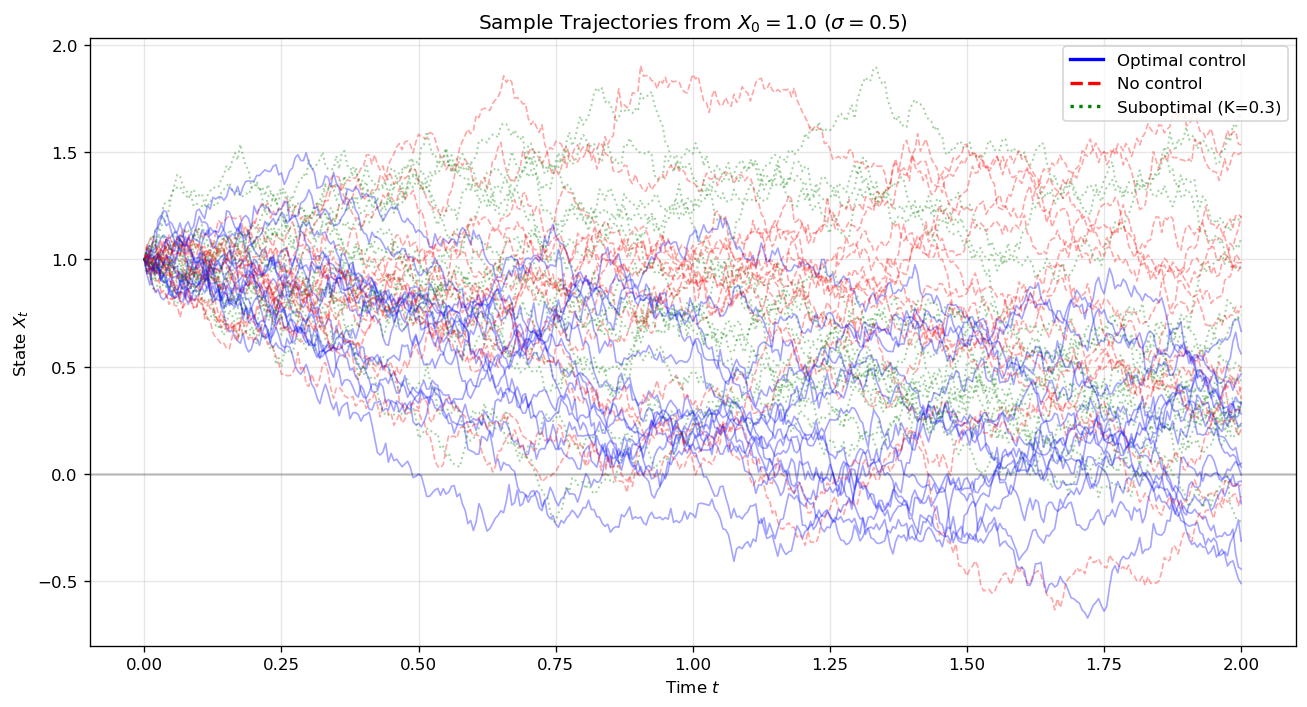

In [14]:
# =============================================================================
# Cell 15: Plot Sample Trajectories
# =============================================================================
fig, ax = plt.subplots(figsize=(11, 6))

# Plot a subset for clarity
n_plot = 15
for j in range(n_plot):
    ax.plot(t_sim, paths_opt[j], 'b-', alpha=0.35, linewidth=1.0)
    ax.plot(t_sim, paths_none[j], 'r--', alpha=0.35, linewidth=1.0)
    ax.plot(t_sim, paths_sub[j], 'g:', alpha=0.35, linewidth=1.2)

# Dummy lines for legend
ax.plot([], [], 'b-', linewidth=2, label='Optimal control')
ax.plot([], [], 'r--', linewidth=2, label='No control')
ax.plot([], [], 'g:', linewidth=2, label='Suboptimal (K=0.3)')

ax.axhline(0.0, color='black', linestyle='-', alpha=0.2)
ax.set_xlabel('Time $t$')
ax.set_ylabel('State $X_t$')
ax.set_title(rf'Sample Trajectories from $X_0 = {x0_demo}$ ($\sigma = {sigma}$)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 11. Monte Carlo Verification

The value function $V(0, x_0)$ should equal the expected total cost when using the optimal policy. We verify this by running thousands of Monte Carlo simulations and comparing the sample mean to the analytical $V(0, x_0)$.


MONTE CARLO VERIFICATION
Analytical V(0, 1.0) = 1.6121
Optimal MC mean cost      = 1.6209
Optimal MC std error      = 0.0099
No-control MC mean cost   = 5.5378


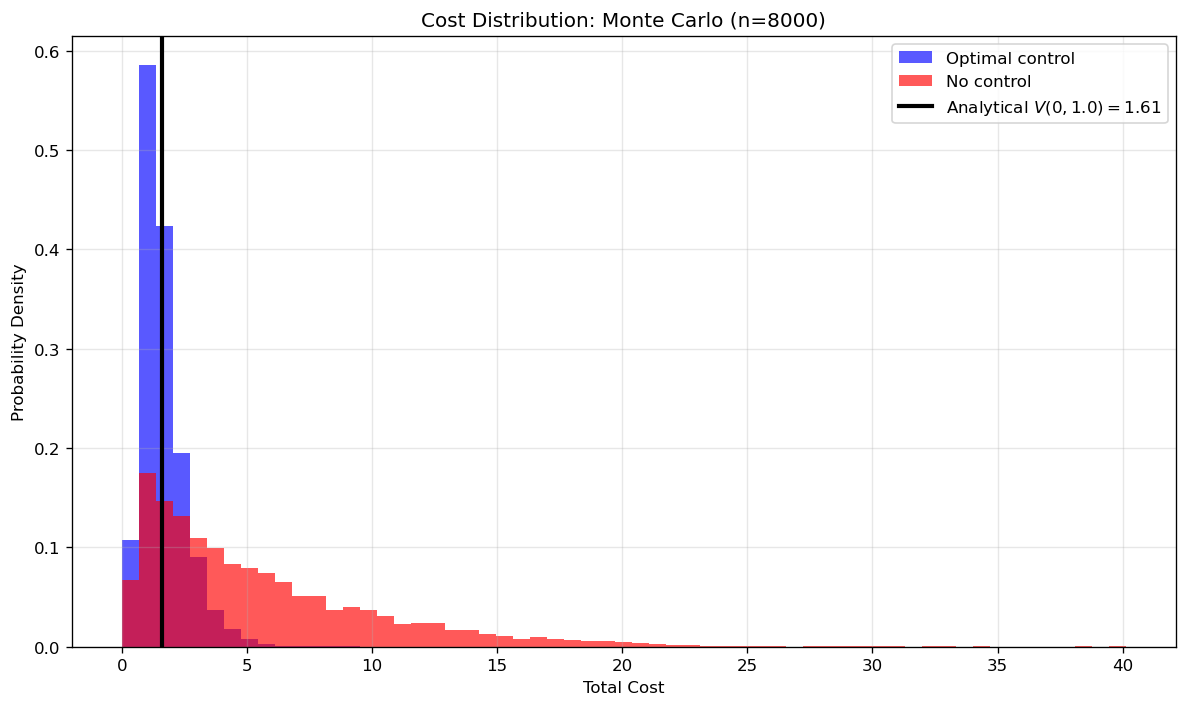

In [15]:
# =============================================================================
# Cell 17: Monte Carlo Cost Comparison
# =============================================================================
np.random.seed(123)

# Run large-scale Monte Carlo
t_mc, paths_mc_opt, costs_mc_opt = simulate_sde(
    x0_demo, T, sigma, P, t, n_paths=8000, dt=0.005, control_type='optimal'
)
t_mc, paths_mc_none, costs_mc_none = simulate_sde(
    x0_demo, T, sigma, P, t, n_paths=8000, dt=0.005, control_type='none'
)

V_analytical = P[0] * x0_demo**2 + g[0]

print("=" * 55)
print("MONTE CARLO VERIFICATION")
print("=" * 55)
print(f"Analytical V(0, {x0_demo}) = {V_analytical:.4f}")
print(f"Optimal MC mean cost      = {np.mean(costs_mc_opt):.4f}")
print(f"Optimal MC std error      = {np.std(costs_mc_opt)/np.sqrt(len(costs_mc_opt)):.4f}")
print(f"No-control MC mean cost   = {np.mean(costs_mc_none):.4f}")
print("=" * 55)

# Histogram of cost distributions
fig, ax = plt.subplots(figsize=(10, 6))

bins = np.linspace(0, max(costs_mc_none.max(), costs_mc_opt.max()), 60)
ax.hist(costs_mc_opt, bins=bins, alpha=0.65, color='blue', 
        density=True, label='Optimal control')
ax.hist(costs_mc_none, bins=bins, alpha=0.65, color='red', 
        density=True, label='No control')

ax.axvline(V_analytical, color='black', linestyle='-', linewidth=2.5,
           label=rf'Analytical $V(0,{x0_demo}) = {V_analytical:.2f}$')

ax.set_xlabel('Total Cost')
ax.set_ylabel('Probability Density')
ax.set_title('Cost Distribution: Monte Carlo (n=8000)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 12. Verifying the HJB Equation Numerically

Since we have the analytical solution, we can check that it actually satisfies the PDE. We compute the partial derivatives $\partial_t V$, $\partial_x V$, $\partial_{xx} V$ numerically and evaluate the HJB residual:

$$\text{Residual} = \partial_t V + qx^2 - \frac{(\partial_x V)^2}{4r} + \frac{\sigma^2}{2}\partial_{xx} V$$

For the true solution, this should be zero everywhere (up to numerical differentiation error).


Max absolute residual: 8.039394e-01
Mean absolute residual: 4.473506e-03


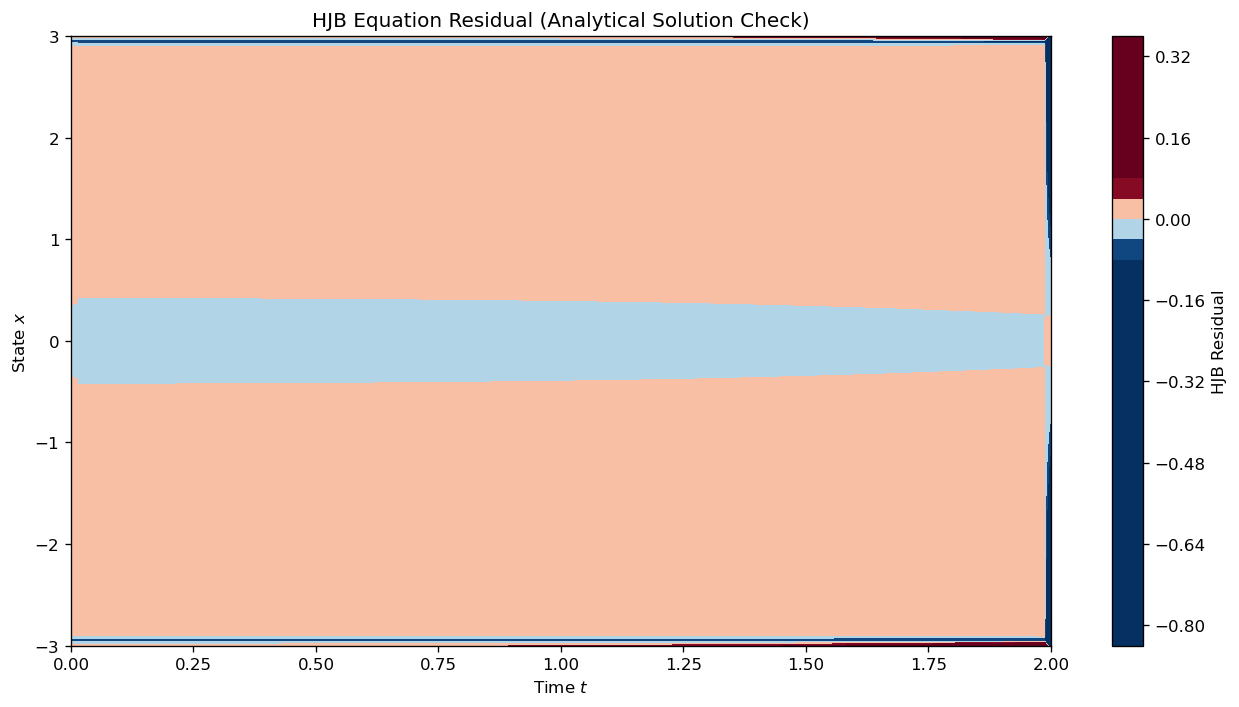

In [16]:
# =============================================================================
# Cell 19: HJB Equation Residual Verification
# =============================================================================

# Numerical partial derivatives
dt_grid = t[1] - t[0]
dx_grid = x[1] - x[0]

V_t = np.gradient(V, dt_grid, axis=0)
V_x = np.gradient(V, dx_grid, axis=1)
V_xx = np.gradient(V_x, dx_grid, axis=1)

# HJB residual
residual = V_t + q * X_grid**2 - (V_x**2) / (4.0 * r) + (sigma**2 / 2.0) * V_xx

print(f"Max absolute residual: {np.max(np.abs(residual)):.6e}")
print(f"Mean absolute residual: {np.mean(np.abs(residual)):.6e}")

# Plot residual
fig, ax = plt.subplots(figsize=(11, 6))

# Use symmetric color scale for better visibility
vmax = np.percentile(np.abs(residual), 98)
cs = ax.contourf(T_grid, X_grid, residual, levels=30, cmap=cm.RdBu_r,
                  vmin=-vmax, vmax=vmax)
plt.colorbar(cs, ax=ax, label='HJB Residual')
ax.set_xlabel('Time $t$')
ax.set_ylabel('State $x$')
ax.set_title('HJB Equation Residual (Analytical Solution Check)')
plt.tight_layout()
plt.show()


## 13. Summary: Key Takeaways

| Concept | Description |
|---------|-------------|
| **Value Function** $V(t,x)$ | Minimum expected future cost from state $x$ at time $t$. Solves the HJB PDE. |
| **HJB Equation** | Nonlinear PDE combining optimization (Hamiltonian) + diffusion (second derivative). |
| **Optimal Feedback** $u^*(t,x)$ | Obtained by pointwise minimization inside the HJB equation. |
| **Riccati ODE** | For LQR problems, the HJB reduces to a matrix/scalar ODE for the quadratic coefficient. |
| **Verification** | A smooth solution to HJB + associated feedback control yields the true optimal policy. |

### Why HJB matters
- It transforms a **stochastic optimization over paths** into a **deterministic PDE** over the state space.
- The feedback policy $u^*(t, x)$ is robust: it tells you what to do for *any* state you might encounter, not just the expected trajectory.
- In higher dimensions, solving HJB analytically is rare; this is where **numerical PDE methods** (finite differences, deep learning, etc.) become essential.
- 